In [18]:
import pickle
import json

from matplotlib import pyplot as plt

from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

In [2]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_data = json.load(f)["performance_scores"]


In [15]:
SEG_results_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/ensemble_scores/to_Hoechst/SEG_results.pkl"
with open(SEG_results_path, "rb") as f:
    SEG_results = pickle.load(f)

In [16]:
methods = SEG_results["methods"]
agree_ratios = SEG_results["agree_ratios"]
radii = SEG_results["radii"]
weights = SEG_results["weights"]
eq_f1s = SEG_results["eq_f1s"]
uneq_f1s = SEG_results["uneq_f1s"]
target = SEG_results["target"]

In [ ]:
for r in radii:
    kt_eq = []
    sp_eq = []
    pe_eq = []
    kt_uneq = []
    sp_uneq = []
    pe_uneq = []

    for agree_ratio in agree_ratios:
        print(f"Radius: {r}, Agree ratio: {agree_ratio}")
        f1s_uneq: dict[str, float] = {}
        f1s_eq: dict[str, float] = {}
        for i, m in enumerate(methods):
            f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
            f1s_eq[m] = eq_f1s[r][agree_ratio][i]
        
        performance_scores = {target: performance_data[target]}
        SEG_scores_uneq = {target: f1s_uneq}
        SEG_scores_eq = {target: f1s_eq}

        KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_eq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
            )
        
        correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=[target])
        print("eq_weight")
        print(correlation_df_eq)

        KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_uneq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
        )
        correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=[target])
        print("uneq_weight")
        print(correlation_df_uneq)

Radius: 20, Agree ratio: 0.25
eq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.2     0.82    0.3        0.67  0.45     0.44
uneq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.2     0.74    0.2        0.77  0.31     0.61
Radius: 20, Agree ratio: 0.5
eq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.8     0.08    0.9        0.07  0.76     0.14
uneq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito Hoechst  0.4     0.48    0.4        0.49  0.66     0.23
Radius: 20, Agree ratio: 0.75
eq_weight
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mit

Radius: 20, Agree ratio: 0.25
Radius: 22, Agree ratio: 0.25
Radius: 24, Agree ratio: 0.25
Radius: 26, Agree ratio: 0.25
Radius: 28, Agree ratio: 0.25
Radius: 30, Agree ratio: 0.25


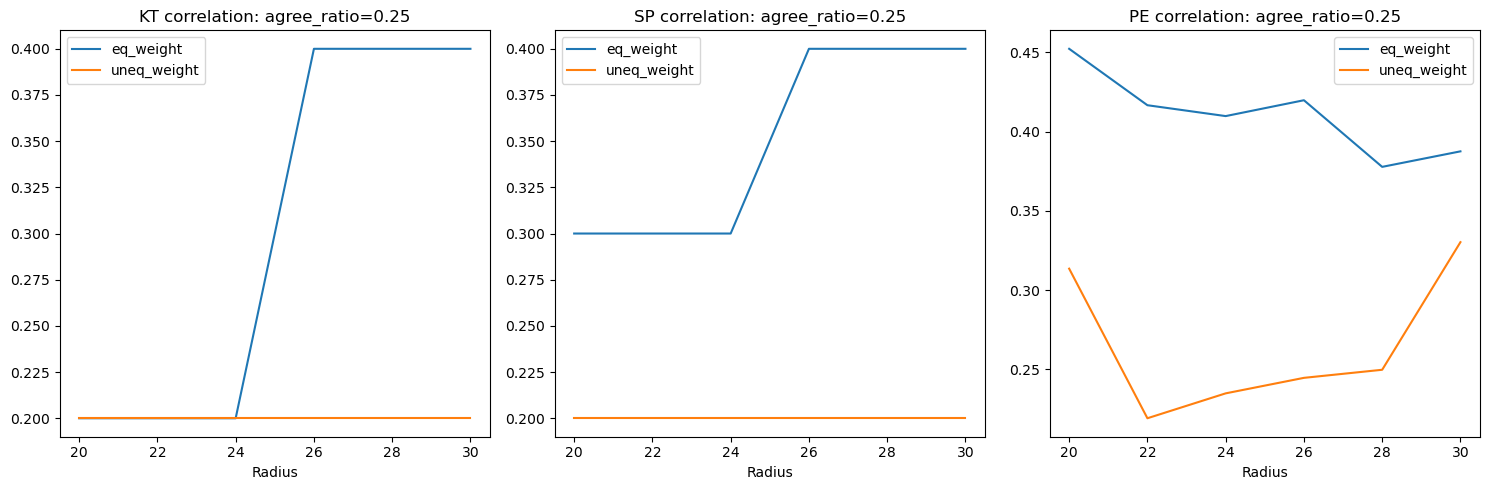

Radius: 20, Agree ratio: 0.5
Radius: 22, Agree ratio: 0.5
Radius: 24, Agree ratio: 0.5
Radius: 26, Agree ratio: 0.5
Radius: 28, Agree ratio: 0.5
Radius: 30, Agree ratio: 0.5


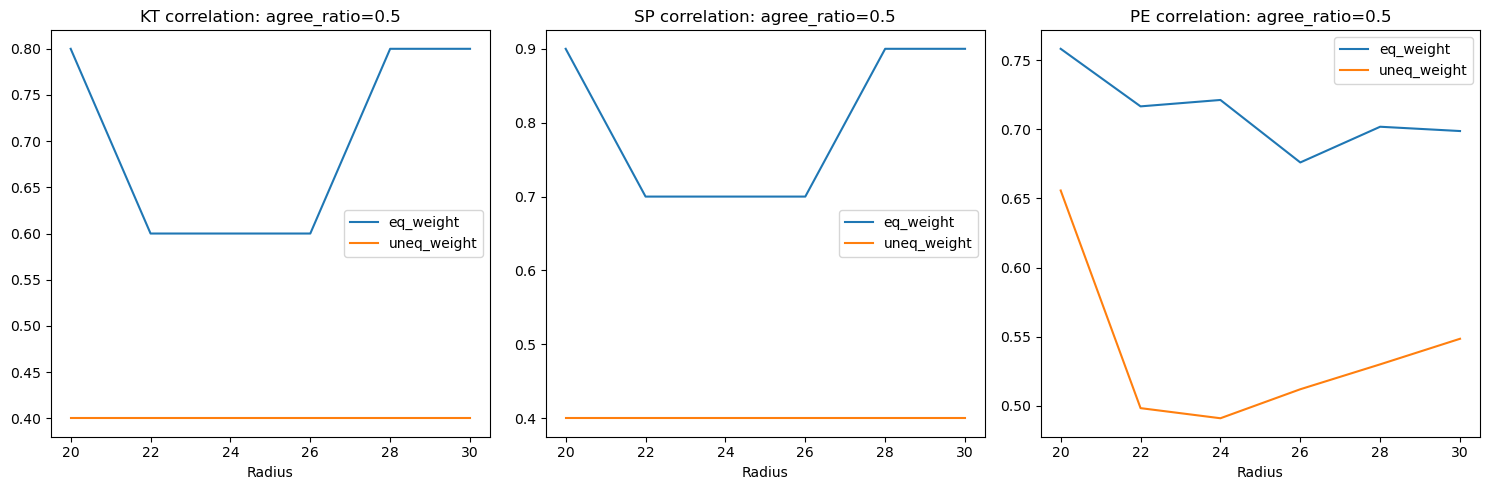

Radius: 20, Agree ratio: 0.75
Radius: 22, Agree ratio: 0.75
Radius: 24, Agree ratio: 0.75
Radius: 26, Agree ratio: 0.75
Radius: 28, Agree ratio: 0.75
Radius: 30, Agree ratio: 0.75


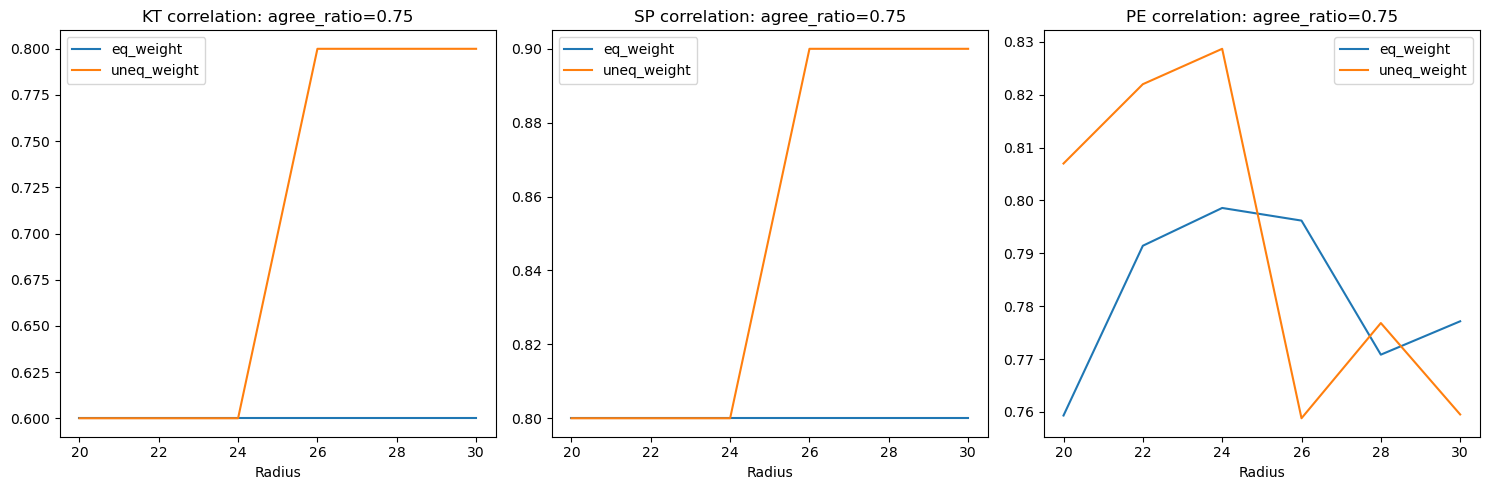

In [22]:
for agree_ratio in agree_ratios:
    kt_eq = []
    sp_eq = []
    pe_eq = []
    kt_uneq = []
    sp_uneq = []
    pe_uneq = []
    for r in radii:
        print(f"Radius: {r}, Agree ratio: {agree_ratio}")
        f1s_uneq: dict[str, float] = {}
        f1s_eq: dict[str, float] = {}
        for i, m in enumerate(methods):
            f1s_uneq[m] = uneq_f1s[r][agree_ratio][i]
            f1s_eq[m] = eq_f1s[r][agree_ratio][i]
        
        performance_scores = {target: performance_data[target]}
        SEG_scores_uneq = {target: f1s_uneq}
        SEG_scores_eq = {target: f1s_eq}

        KT_scores_eq, SP_scores_eq, PE_scores_eq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_eq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
            )
        
        kt_eq.append(KT_scores_eq[0,0,0])
        sp_eq.append(SP_scores_eq[0,0,0])
        pe_eq.append(PE_scores_eq[0,0,0])

        # correlation_df_eq = correlation_table(KT_scores_eq, SP_scores_eq, PE_scores_eq, targets=[target])
        # print("eq_weight")
        # print(correlation_df_eq)

        KT_scores_uneq, SP_scores_uneq, PE_scores_uneq = to_target_transfer_correlations(
            targets=[target],
            transfer_metric_per_target=SEG_scores_uneq,
            performance_per_target=performance_scores,
            invert_transfer_metric=False,
        )
        # correlation_df_uneq = correlation_table(KT_scores_uneq, SP_scores_uneq, PE_scores_uneq, targets=[target])
        # print("uneq_weight")
        # print(correlation_df_uneq)
        kt_uneq.append(KT_scores_uneq[0,0,0])
        sp_uneq.append(SP_scores_uneq[0,0,0])
        pe_uneq.append(PE_scores_uneq[0,0,0])
    
    f, ax = plt.subplots(1,3, figsize=(15,5))
    ax = ax.flatten()
    ax[0].plot(radii, kt_eq, label="eq_weight")
    ax[0].plot(radii, kt_uneq, label="uneq_weight")
    ax[0].set_title(f"KT correlation: agree_ratio={agree_ratio}")
    ax[0].set_xlabel("Radius")
    ax[0].legend()

    ax[1].plot(radii, sp_eq, label="eq_weight")
    ax[1].plot(radii, sp_uneq, label="uneq_weight")
    ax[1].set_title(f"SP correlation: agree_ratio={agree_ratio}")
    ax[1].set_xlabel("Radius")
    ax[1].legend()

    ax[2].plot(radii, pe_eq, label="eq_weight")
    ax[2].plot(radii, pe_uneq, label="uneq_weight")
    ax[2].set_title(f"PE correlation: agree_ratio={agree_ratio}")
    ax[2].set_xlabel("Radius")
    ax[2].legend()
    plt.tight_layout()
    plt.show()